In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()
import yfinance 

from sklearn.decomposition import PCA 
from sklearn.model_selection import train_test_split 

In [ ]:
### import data 

filePath = '/mnt/G/python/data/Dow/data.csv'
data = pd.read_csv(filePath, parse_dates=True, index_col='Date')
data.index = pd.to_datetime(data.index)
data.head()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,DWDP,...,PFE,PG,TRV,UTX,UNH,VZ,V,WMT,WBA,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-29,84.129997,40.880001,7.467857,55.209999,58.180000,77.209999,24.100000,28.870001,32.380001,NaN,...,17.609108,61.580002,49.869999,NaN,30.850000,31.353628,22.004999,54.110001,37.230000,10545.410156
2009-12-30,83.900002,40.799999,7.558571,54.959999,58.049999,77.650002,24.180000,28.840000,32.279999,NaN,...,17.552181,61.369999,50.259998,NaN,31.010000,31.344250,22.035000,54.299999,37.130001,10548.509766
2009-12-31,82.669998,40.520000,7.526071,54.130001,56.990002,76.989998,23.940001,28.500000,32.250000,NaN,...,17.258064,60.630001,49.860001,NaN,30.480000,31.072264,21.865000,53.450001,36.720001,10428.049805
2010-01-04,83.019997,40.919998,7.643214,56.180000,58.549999,79.059998,24.690001,28.520000,32.070000,NaN,...,17.960152,61.119999,49.810001,NaN,31.530001,31.212946,22.035000,54.230000,37.299999,10583.959961
2010-01-05,82.500000,40.830002,7.656429,58.020000,59.250000,79.620003,24.580000,28.174999,31.990000,NaN,...,17.703985,61.139999,48.630001,NaN,31.480000,31.269218,21.782499,53.689999,37.000000,10572.019531


In [ ]:
dow = data['^DJI']
df = data.drop(['^DJI', 'DWDP', 'UTX'], axis=1)

### performance over the years 

In [ ]:
df.iloc[1, : ] / df.iloc[0, :]

MMM     0.997266
AXP     0.998043
AAPL    1.012147
BA      0.995472
CAT     0.997766
CVX     1.005699
CSCO    1.003319
KO      0.998961
DIS     0.996912
XOM     0.998983
GS      1.015720
HD      0.995217
IBM     1.005461
INTC    1.009314
JNJ     0.999538
JPM     1.000964
MCD     0.988992
MRK     0.998922
MSFT    0.986301
NKE     0.998943
PFE     0.996767
PG      0.996590
TRV     1.007820
UNH     1.005186
VZ      0.999701
V       1.001363
WMT     1.003511
WBA     0.997314
dtype: float64

In [ ]:
# annualized return 
ret_annulized = ((df.iloc[-1, :] / df.iloc[0, :]) ** (250/len(df)))-1

# daily return 
ret_daily = df.pct_change().dropna()

# annualized std 
std_annualized = ret_daily.std() * np.sqrt(252)

# cumulative return
ret_cumulative = (1+ret_daily).cumprod() - 1.

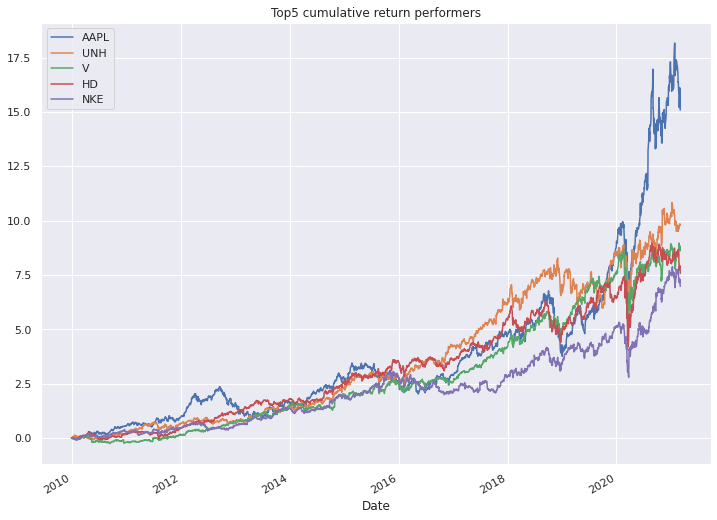

In [ ]:
ret_cumulative.iloc[:, ret_cumulative.iloc[-1, :].values.argsort()[::-1]].iloc[:, :5].plot(figsize=(12,9))
plt.title('Top5 cumulative return performers');

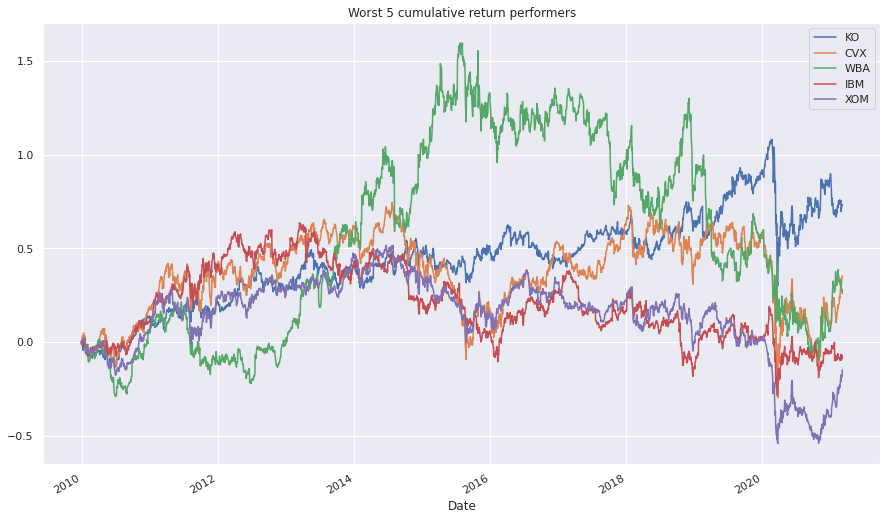

In [ ]:
ret_cumulative.iloc[:, ret_cumulative.iloc[-1, :].values.argsort()[::-1]].iloc[:, -5:].plot(figsize=(15,9))
plt.title('Worst 5 cumulative return performers');

### PCA 

In [ ]:
pca = PCA()
pca.fit(ret_daily)

PCA()

In [ ]:
pcs = pca.components_   # principle components 
                        # using as portfolio weights 

### Asset allocation and performance 

In [ ]:
#pc1 = pcs[0]
weights = np.abs(pcs) / np.sum(np.abs(pcs), axis=0)

In [ ]:
port_ret = np.dot(ret_daily, weights)
mkt_ret = dow.pct_change().dropna()

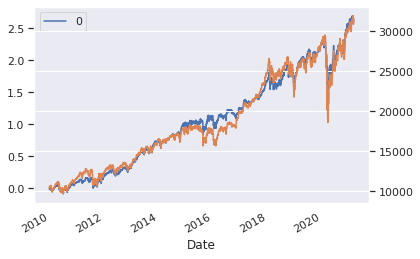

In [ ]:
tmp = (1+port_ret[:, 0]).cumprod() - 1
pd.DataFrame(tmp).set_index(dow.index[1:]).plot()
dow.plot(secondary_y=True);

### PCA porfolio 

- see [PRINCIPAL COMPONENT ANALYSIS IN PORTFOLIO MANAGEMENT](https://systematicedge.wordpress.com/2013/06/02/principal-component-analysis-in-portfolio-management/)

- assume: no short-selling (weights should be positive number)

- $\underset{k\times k}{R_p} =\text{eVector}^{-1} \cdot R$

   - $R_p$: each column $k$-different principal returns with  eigenvector as weights

   - loadings = $\text{eVector} \cdot \sqrt{\text{eValue}}$

In [ ]:
#df: normalized dow 
#projected: pct to time dimension
eVec = pca.components_.copy()

In [ ]:
#np.linalg.inv(eVec)
ret_port = np.dot(np.linalg.inv(eVec).T, ret_daily.T).T

In [ ]:
df_ret_port = pd.DataFrame(ret_port).set_index(ret_daily.index)

In [ ]:
df_ret_port_accum = (df_ret_port + 1.).cumprod()

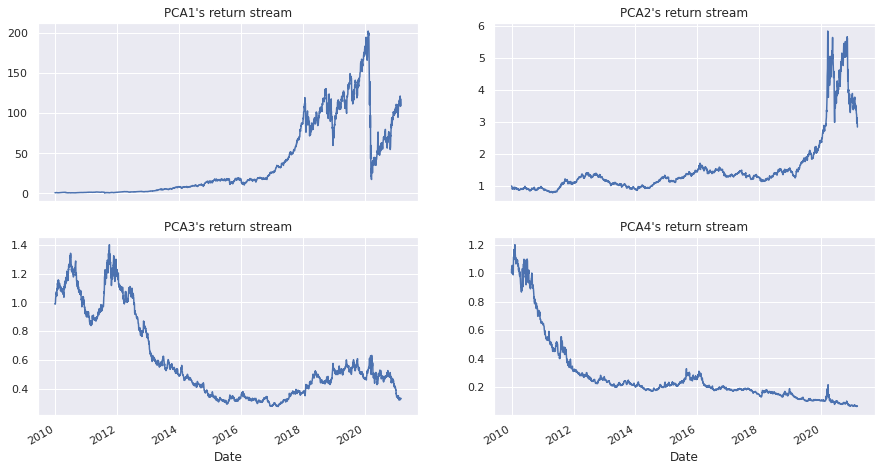

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(15,8), sharex=True)
df_ret_port_accum.iloc[:, 0].plot(ax=axs[0,0])
axs[0,0].set_title("PCA1's return stream")
df_ret_port_accum.iloc[:, 1].plot(ax=axs[0,1])
axs[0,1].set_title("PCA2's return stream")
df_ret_port_accum.iloc[:, 2].plot(ax=axs[1,0])
axs[1,0].set_title("PCA3's return stream")
df_ret_port_accum.iloc[:, 3].plot(ax=axs[1,1])
axs[1,1].set_title("PCA4's return stream");

In [ ]:
(df_ret_port + 1.).cumprod(axis=0)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-30,0.997105,0.997558,0.989821,1.000640,1.013274,1.001070,1.001470,0.995907,1.012052,0.997710,...,0.999160,0.991597,0.999288,1.007248,0.987548,1.004366,1.010661,1.002084,1.002061,1.003480
2009-12-31,0.961017,0.999021,0.987250,1.030826,1.019527,1.012395,0.993836,0.978375,1.012310,1.000307,...,1.000868,0.994800,0.996164,0.999998,0.984994,1.000978,1.012009,0.992465,1.005823,1.016500
2010-01-04,1.017081,0.975359,0.993940,1.011382,1.054956,1.007892,1.005231,0.998483,1.041094,1.015718,...,1.002784,0.993890,1.007539,1.015902,0.995028,1.018264,1.036806,1.017802,0.983220,0.996189
2010-01-05,1.029423,0.953397,1.012184,1.030660,1.081992,1.015357,1.011397,0.992274,1.043367,1.008480,...,1.009804,1.000664,0.999257,1.014664,1.005060,1.022401,1.034574,1.013892,0.986391,1.008962
2010-01-06,1.035928,0.922856,1.026275,1.040703,1.080973,1.002816,1.021204,1.011170,1.052084,1.003194,...,1.002178,1.011106,0.979356,1.018243,1.019725,1.004530,1.039865,0.983700,0.985686,0.991962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-26,108.402904,3.132286,0.332852,0.064376,1.322540,2.318197,3.725448,0.918628,0.438889,0.682869,...,0.952148,0.456271,1.302982,1.788260,0.580777,2.990309,2.229036,1.820195,0.771801,0.555931
2021-03-01,117.771355,3.043234,0.331223,0.062027,1.362104,2.404289,3.790476,0.913837,0.433430,0.678765,...,0.951260,0.443884,1.316721,1.843902,0.579113,2.994122,2.283566,1.859626,0.774320,0.550764
2021-03-02,115.718643,3.018326,0.330181,0.062648,1.351956,2.399590,3.734477,0.915114,0.437209,0.684822,...,0.948909,0.449662,1.315055,1.823371,0.581149,2.987126,2.253945,1.833182,0.780494,0.548076
